<a href="https://colab.research.google.com/github/sihanma666/eng-ai-agents/blob/main/assignments/assignment-1/01_assignment_part_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [ ]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [ ]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [ ]:
# Compute correct empirical covariances
samples_lr = sample(W0 + DeltaW_lr)
samples_dense = sample(W0 + DeltaW_dense)

S_lr = (samples_lr.T @ samples_lr) / n
S_dense = (samples_dense.T @ samples_dense) / n

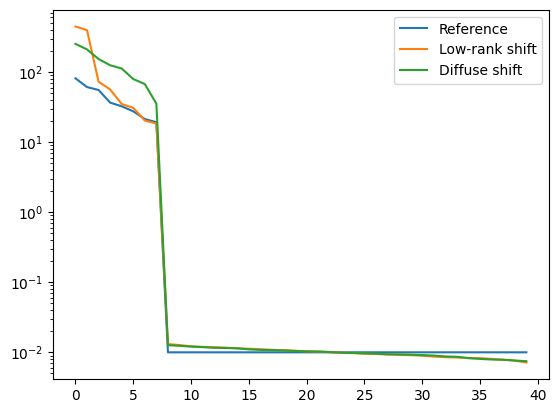

In [ ]:
eig0 = eigvalsh(Sigma0)[::-1]
eig_lr = eigvalsh(S_lr)[::-1]
eig_dense = eigvalsh(S_dense)[::-1]

plt.semilogy(eig0, label='Reference')
plt.semilogy(eig_lr, label='Low-rank shift')
plt.semilogy(eig_dense, label='Diffuse shift')
plt.legend()
plt.show()

In [ ]:
print("First 10 absolute changes:")
print(f"Low-rank: {eig_lr[:10] - eig0[:10]}")
print(f"Diffuse:  {eig_dense[:10] - eig0[:10]}")

First 10 absolute changes:
Low-rank: [ 3.64618515e+02  3.33991367e+02  1.72187514e+01  1.98465772e+01
  2.50134650e+00  3.32427848e+00 -1.02696976e+00 -8.40061669e-01
  3.11746550e-03  2.68483798e-03]
Diffuse:  [1.70508618e+02 1.48989601e+02 9.77412591e+01 8.81711045e+01
 7.96820064e+01 5.18028409e+01 4.59171358e+01 1.60904502e+01
 2.63221365e-03 2.38905313e-03]


In [ ]:
threshold = 0.10

# relative_diff = |new_value - old_value| / old_value
relative_diff_lr = np.abs(eig_lr - eig0) / eig0
relative_diff_dense = np.abs(eig_dense - eig0) / eig0

#count of eigenvalues that exceed threshold
num_changed_lr = np.sum(relative_diff_lr > threshold)
num_changed_dense = np.sum(relative_diff_dense > threshold)

print("First 10 relative differences (low-rank):")
print(relative_diff_lr[:10])
print("\nFirst 10 relative differences (diffuse):")
print(relative_diff_dense[:10])

#print results
print(f"low-rank modifications: {num_changed_lr} eigenvalues changed significantly")
print(f"diffuse modifactions: {num_changed_dense} eigenvalues changed significantly")

First 10 relative differences (low-rank):
[4.48537676 5.48447717 0.3110378  0.5430749  0.07723652 0.12101213
 0.04819243 0.04376644 0.31174655 0.2684838 ]

First 10 relative differences (diffuse):
[2.0975221  2.44656043 1.76558833 2.41268372 2.46041902 1.88575419
 2.15474527 0.8382976  0.26322137 0.23890531]
low-rank modifications: 24 eigenvalues changed significantly
diffuse modifactions: 25 eigenvalues changed significantly


1. In the low-rank case, 24 eigenvalues changed by more than 10%. However because of the low rank modification (ΔW = BA) where B is 40x2 and A is 2x8, the modification can only add variance for 2 independent directions in the 40-dimensional space. So, these 2 directions become the dominant eigenvalue directions where the change is concentrated. This shows up in how the first 2 eigenvalues increased by 428% and 527% respectively, while the third only increased by 29%.

2. In the diffuse case, 27 eigenvalues changed by more than 10% and these changes were distributed more evely. Since the diffuse modification has approximately full rank, many eigenvalues were affected. This modification added variance along many independent directions at the same time. So despite the overall magnitude (Frobenius norm) of change being the same as for low-rank, no single eigenvalue dominates.

3. The matrix rank represents the number of independent directions that a matrix spans. Eigenvalues represent variance magnitudes along geometric directions and eigenvectors define those directions. A rank-r modification can only alter r eigenvalue/eigenvector pairs significantly.This is why our low rank modification could only introduce new variance along 2 independent geometric directions in the 40-dimensional covariance space while the diffuse modidication could introduce variance in many more independent, evenly distributed directions.